In [1]:
import numpy as np # only math engine
from sklearn.metrics import classification_report, confusion_matrix
import matplotlib.pyplot as plt  # you'll need this eventually for loss plots
import pandas as pd  # data manipulation and exporting to csv/excel
from tqdm import tqdm
import time
import os
from google.colab import drive
drive.mount('/content/drive')

# Optional: set random seed for reproducibility
randseed = np.random.seed(42)

print("NumPy version:", np.__version__)
print("Setup complete – ready to build data and model.")
print("NP random seed: ", np.random.seed(42))

Mounted at /content/drive
NumPy version: 2.0.2
Setup complete – ready to build data and model.
NP random seed:  None


In [2]:
%cd "drive/MyDrive/Colab Notebooks/MIS 769/Project"

/content/drive/MyDrive/Colab Notebooks/MIS 769/Project


# Training

### 1. Loading the Dataset

We begin by loading the training dataset from the Excel file `Training_Set_2575.xlsx`.

The dataset contains:
- `Masked_Text`: The input text with sensitive information already masked.
- `Binary_Label`: The target variable (1 = contains PII, 0 = does not contain PII).

We extract the raw text into `X_raw` and the labels into `y` for further processing.

In [3]:
df = pd.read_excel('Training_Set_2575.xlsx', sheet_name='Training_Set')

X_raw = df['Masked_Text'].astype(str).values
y = df['Binary_Label'].values

print(f"Loaded {len(df):,} rows")
print(f"Class balance: {np.mean(y):.1%} positive (has PII)")
print(f"X_raw shape: {X_raw.shape}, y shape: {y.shape}")

Loaded 45,000 rows
Class balance: 24.8% positive (has PII)
X_raw shape: (45000,), y shape: (45000,)


### 2. Loading GloVe Word Embeddings

We use the pre-trained **GloVe 6B 300d** word embeddings from Stanford University.  
These 300-dimensional vectors were trained on 6 billion tokens and provide rich semantic representations.

The embeddings file was downloaded from:  
[https://nlp.stanford.edu/data/glove.6B.zip](https://nlp.stanford.edu/data/glove.6B.zip)

We load the 300d vectors into a dictionary `embeddings_index` for fast word-to-vector lookup.

In [4]:
print("Loading GloVe embeddings... (this may take 30-60 seconds)")

embeddings_index = {}
with open('glove.6B.300d.txt', encoding='utf-8') as f:
    for line in tqdm(f, total=400000):
        values = line.split()
        word = values[0]
        coefs = np.asarray(values[1:], dtype='float32')
        embeddings_index[word] = coefs

print(f"Loaded {len(embeddings_index):,} word vectors.")

Loading GloVe embeddings... (this may take 30-60 seconds)


100%|██████████| 400000/400000 [00:46<00:00, 8626.81it/s]

Loaded 400,000 word vectors.


### 3. Converting Text to Embeddings

To create numerical features from the raw text, we convert each document into a fixed-size vector using **average GloVe embeddings**.

For every text sample:
- We split the text into words
- Take only the words present in the GloVe vocabulary
- Compute the **mean** of their 300-dimensional vectors

This produces a simple but effective document-level embedding. Documents with no known words receive a zero vector.

In [5]:
print("Creating average embeddings for 45,000 documents...")

def text_to_embedding(text, embeddings_index, dim=300):
    words = text.lower().split()
    valid_vectors = [embeddings_index[word] for word in words if word in embeddings_index]
    if len(valid_vectors) == 0:
        return np.zeros(dim, dtype=np.float32)
    return np.mean(valid_vectors, axis=0)

X_emb = np.zeros((len(X_raw), 300), dtype=np.float32)

for i in tqdm(range(len(X_raw))):
    X_emb[i] = text_to_embedding(X_raw[i], embeddings_index)

print(f"\n✅ Done! X_emb shape: {X_emb.shape}")

Creating average embeddings for 45,000 documents...


100%|██████████| 45000/45000 [00:10<00:00, 4451.88it/s]


✅ Done! X_emb shape: (45000, 300)


### 4. Building the Neural Network from Scratch

We implement a simple feedforward neural network (`ScratchNet`) using only NumPy.

**Architecture:**
- Input layer: 300 dimensions (GloVe average embedding)
- Two hidden layers: 256 → 128 neurons with **ReLU** activation
- Output layer: 1 neuron with sigmoid activation (binary classification)

Key features implemented:
- **He initialization** for ReLU layers
- **Dropout** (during training only) for regularization
- **Forward pass** with ReLU and dropout
- **Backward pass** with backpropagation (including ReLU derivative)
- **SGD optimizer** with optional L2 weight decay

This class allows full control and understanding of every step in the training process.

In [6]:
class ScratchNet:
    def __init__(self, input_size=300, hidden_sizes=[256, 128], dropout=0.5):
        self.layers = []
        prev_size = input_size

        # Hidden layers with He initialization
        for h in hidden_sizes:
            W = np.random.randn(prev_size, h) * np.sqrt(2.0 / prev_size)
            b = np.zeros((1, h))
            self.layers.append({'W': W, 'b': b})
            prev_size = h

        # Output layer (binary)
        W_out = np.random.randn(prev_size, 1) * np.sqrt(2.0 / prev_size)
        b_out = np.zeros((1, 1))
        self.layers.append({'W': W_out, 'b': b_out})

        self.dropout = dropout
        self.training = True
        self.activations = None
        self.dropout_masks = None

    def forward(self, X):
        X = np.asarray(X, dtype=np.float32)
        if X.ndim == 1:
            X = X.reshape(1, -1)

        activations = [X]
        dropout_masks = []

        # Hidden layers
        for layer in self.layers[:-1]:
            Z = activations[-1] @ layer['W'] + layer['b']
            A = np.maximum(0, Z)  # ReLU

            if self.training and self.dropout > 0:
                mask = (np.random.rand(*A.shape) > self.dropout) / (1 - self.dropout)
                A = A * mask
                dropout_masks.append(mask)
            else:
                dropout_masks.append(None)

            activations.append(A)

        # Output logits
        logits = activations[-1] @ self.layers[-1]['W'] + self.layers[-1]['b']
        activations.append(logits)

        self.activations = activations
        self.dropout_masks = dropout_masks
        return logits

    def backward(self, logits, y, pos_weight=2.0):
        y = np.asarray(y, dtype=np.float64).reshape(-1, 1)
        batch_size = y.shape[0]

        sigmoid_out = 1 / (1 + np.exp(-np.clip(logits, -500, 500)))
        current_delta = (sigmoid_out * (1 + (pos_weight - 1) * y)) - (pos_weight * y)

        for i in range(len(self.layers) - 1, -1, -1):
            layer = self.layers[i]
            A_prev = self.activations[i]

            layer['dW'] = A_prev.T @ current_delta / batch_size
            layer['db'] = np.sum(current_delta, axis=0, keepdims=True) / batch_size

            if i > 0:
                current_delta = current_delta @ layer['W'].T
                current_delta *= (self.activations[i] > 0).astype(np.float32)
                if self.dropout_masks[i-1] is not None:
                    current_delta *= self.dropout_masks[i-1]

    def update_parameters(self, lr=0.001, l2_lambda=0.001):
        """Apply SGD update with optional L2 regularization (weight decay)"""
        for layer in self.layers:
            if 'dW' in layer:
                # L2 penalty: weight decay
                layer['W'] -= lr * (layer['dW'] + l2_lambda * layer['W'])
                layer['b'] -= lr * layer['db']

    def predict_proba(self, X):
        self.training = False
        logits = self.forward(X)
        proba = 1 / (1 + np.exp(-np.clip(logits, -500, 500)))
        self.training = True
        return proba.ravel()

### 5. Loss Function

The `stable_bce_loss` function:
- Implements a numerically stable version of BCE to avoid log(0) or exp overflow
- Applies `pos_weight=2.0` to heavily penalize missing positive (PII) cases

This displays the loss recorded as the model learns. The loss applied via gradients (in ScratchNet.backward()) is the derivative of the value calculated here.

In [7]:
def stable_bce_loss(logits: np.ndarray, y: np.ndarray, pos_weight=2.0) -> float:
    logits = np.asarray(logits, dtype=np.float64).ravel()
    y = np.asarray(y, dtype=np.float64).ravel()

    # The mathematically correct stable weighted BCE
    # This matches the derivative: (sigmoid * (1 + (w-1)y)) - (w * y)
    loss_terms = (
        (1 - y) * np.maximum(logits, 0) +
        (1 - y) * np.log1p(np.exp(-np.abs(logits))) +
        y * pos_weight * (np.maximum(-logits, 0) + np.log1p(np.exp(-np.abs(logits))))
    )

    return np.mean(loss_terms)

### 6. Training the Model

We train the `ScratchNet` model on the masked dataset using mini-batch gradient descent.

**Hyperparameters:**
- Hidden layers: `[512, 256]`
- Learning rate: `0.00375`
- Epochs: `60`
- Batch size: `128`
- Dropout: `0.1`
- L2 weight decay: `0.005`
- Weighted BCE loss (`pos_weight=2.0`)

The model is trained with full backpropagation. Training progress (loss and accuracy) is printed every epoch.
After training, the model weights are saved for later use.

In [23]:
# ====================== TRAINING ON THE NEW MASKED DATASET ======================
model = ScratchNet(input_size=300, hidden_sizes=[512, 256], dropout=0.1)

lr = 0.00375
epochs = 60
batch_size = 128
l2_lambda = 0.005

# Lists to store metrics for later visualization
losses = []
accuracies = []

print("Starting training on masked 25/75 dataset...\n")

for epoch in range(epochs):
    start_time = time.time()

    model.training = True
    epoch_loss = 0.0
    correct = 0

    for start in range(0, len(X_emb), batch_size):
        end = start + batch_size
        X_batch = X_emb[start:end]
        y_batch = y[start:end]

        logits = model.forward(X_batch)
        loss = stable_bce_loss(logits, y_batch)
        epoch_loss += loss * len(y_batch)

        model.backward(logits, y_batch)
        model.update_parameters(lr=lr, l2_lambda=l2_lambda)

        preds = (model.predict_proba(X_batch) >= 0.5).astype(int)
        correct += np.sum(preds == y_batch)

    epoch_loss /= len(X_emb)
    epoch_acc = correct / len(X_emb)

    # Store metrics
    losses.append(epoch_loss)
    accuracies.append(epoch_acc)

    epoch_time = time.time() - start_time

    if (epoch + 1) % 5 == 0 or epoch < 5:
        print(f"Epoch {epoch+1:2d} | Loss: {epoch_loss:.4f} | Acc: {epoch_acc:.4f} | Time: {epoch_time:.1f}s")
    else:
        print(f"Epoch {epoch+1:2d} | Loss: {epoch_loss:.4f} | Acc: {epoch_acc:.4f} | Time: {epoch_time:.1f}s")

# Save the trained weights
np.savez('scratchnet_weights_demo.npz', layers=model.layers)

print("✅ Weights saved as 'scratchnet_weights_demo.npz'")

Starting training on masked 25/75 dataset...

Epoch  1 | Loss: 0.8336 | Acc: 0.7461 | Time: 6.3s
Epoch  2 | Loss: 0.8238 | Acc: 0.7517 | Time: 10.5s
Epoch  3 | Loss: 0.8184 | Acc: 0.7517 | Time: 6.4s
Epoch  4 | Loss: 0.8124 | Acc: 0.7517 | Time: 10.5s
Epoch  5 | Loss: 0.8059 | Acc: 0.7517 | Time: 6.3s
Epoch  6 | Loss: 0.7999 | Acc: 0.7517 | Time: 10.6s
Epoch  7 | Loss: 0.7937 | Acc: 0.7518 | Time: 6.3s
Epoch  8 | Loss: 0.7858 | Acc: 0.7530 | Time: 10.5s
Epoch  9 | Loss: 0.7769 | Acc: 0.7576 | Time: 6.2s
Epoch 10 | Loss: 0.7688 | Acc: 0.7677 | Time: 10.7s
Epoch 11 | Loss: 0.7593 | Acc: 0.7821 | Time: 6.2s
Epoch 12 | Loss: 0.7476 | Acc: 0.7991 | Time: 10.6s
Epoch 13 | Loss: 0.7362 | Acc: 0.8174 | Time: 6.3s
Epoch 14 | Loss: 0.7206 | Acc: 0.8360 | Time: 10.6s
Epoch 15 | Loss: 0.7061 | Acc: 0.8510 | Time: 6.2s
Epoch 16 | Loss: 0.6881 | Acc: 0.8639 | Time: 10.6s
Epoch 17 | Loss: 0.6718 | Acc: 0.8748 | Time: 6.2s
Epoch 18 | Loss: 0.6513 | Acc: 0.8835 | Time: 10.6s
Epoch 19 | Loss: 0.6308 | A

### 7. (Optional) Plot Loss and Accuracy Curves

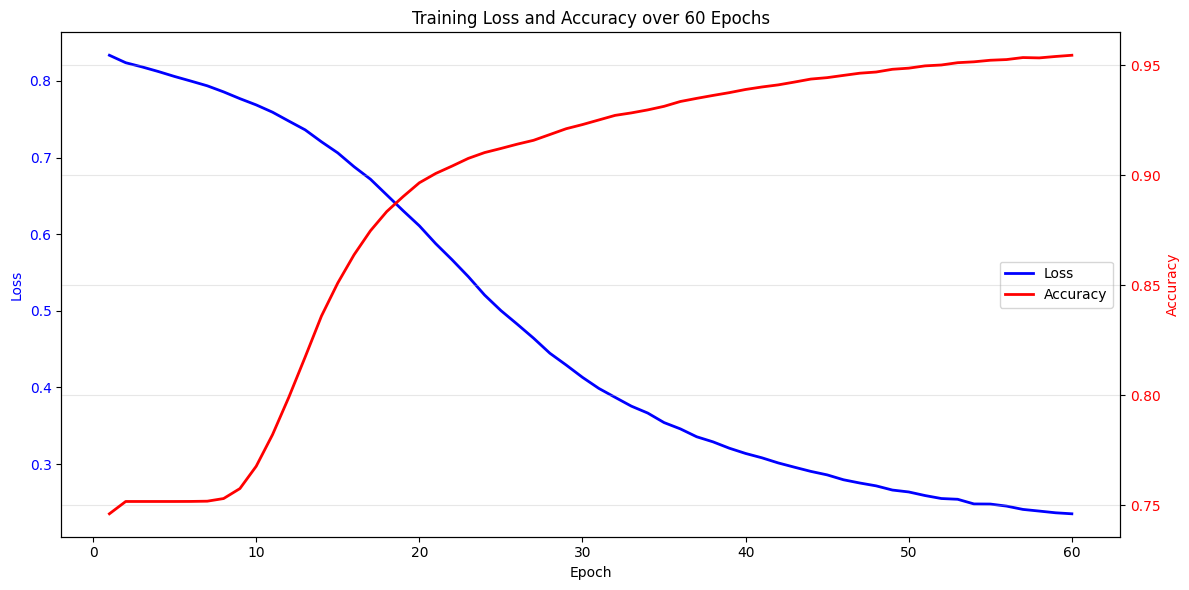

In [24]:
epochs = list(range(1, 61))

# Plotting
fig, ax1 = plt.subplots(figsize=(12, 6))

# Plot Loss
ax1.plot(epochs, losses, 'b-', label='Loss', linewidth=2)
ax1.set_xlabel('Epoch')
ax1.set_ylabel('Loss', color='b')
ax1.tick_params(axis='y', labelcolor='b')

# Create second y-axis for Accuracy
ax2 = ax1.twinx()
ax2.plot(epochs, accuracies, 'r-', label='Accuracy', linewidth=2)
ax2.set_ylabel('Accuracy', color='r')
ax2.tick_params(axis='y', labelcolor='r')

plt.title('Training Loss and Accuracy over 60 Epochs')
plt.grid(True, alpha=0.3)

# Add legend
lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, loc='center right')

plt.tight_layout()
plt.show()

#Testing

### 1. Loading the Test Dataset

We load the separate test set from `Testing_Set.xlsx`.

- `X_raw_test`: Contains the masked text samples  
- `y_test`: Contains the binary PII labels (1 = has PII)

We also verify data integrity by checking for missing values.

In [25]:
# Step 1: Load test data
test_df = pd.read_excel('Testing_Set.xlsx')

X_raw_test = test_df['Masked_Text'].astype(str).values
y_test = test_df['Binary_Label'].values

print(f"✅ Test set loaded: {len(test_df):,} samples")
print(f"Class balance: {np.mean(y_test):.1%} positive")
print(f"X_raw_test shape: {X_raw_test.shape}")
print(f"y_test shape: {y_test.shape}")

# Quick check for missing values
print(f"Missing Masked_Text: {test_df['Masked_Text'].isna().sum()}")
print(f"Missing Binary_Label: {test_df['Binary_Label'].isna().sum()}")

✅ Test set loaded: 30 samples
Class balance: 26.7% positive
X_raw_test shape: (30,)
y_test shape: (30,)
Missing Masked_Text: 0
Missing Binary_Label: 0


### 2. Creating Test Embeddings

We convert the test texts into 300-dimensional embeddings using the **same** `text_to_embedding()` function as in training.

This ensures consistency between training and test data by averaging the GloVe vectors for each document.

In [26]:
# Step 2: Create test embeddings (exact same as training)
print("Creating embeddings for test set...")

X_test = np.zeros((len(X_raw_test), 300), dtype=np.float32)

for i in tqdm(range(len(X_raw_test))):
    X_test[i] = text_to_embedding(X_raw_test[i], embeddings_index)

print(f"✅ Test embeddings created! X_test shape: {X_test.shape}")

Creating embeddings for test set...


100%|██████████| 30/30 [00:00<00:00, 3097.10it/s]

✅ Test embeddings created! X_test shape: (30, 300)


### 3. Loading the Trained Model Weights

We load the best model weights saved during training from the `.npz` file.

First, we inspect the structure of the saved file to confirm it contains the expected layers before restoring them into the model.

In [27]:
# Step 3: Load weights - let's inspect first
weights = np.load('scratchnet_weights_demo.npz', allow_pickle=True)

print("Keys in the npz file:", list(weights.keys()))
print("Type of 'layers':", type(weights['layers']))
print("Shape of 'layers':", weights['layers'].shape if hasattr(weights['layers'], 'shape') else "no shape")

# Show a bit more info
if weights['layers'].ndim == 0:
    print("Content type inside:", type(weights['layers'].item()))

Keys in the npz file: ['layers']
Type of 'layers': <class 'numpy.ndarray'>
Shape of 'layers': (3,)


### 4. Creating and Loading the Model

We instantiate a new `ScratchNet` model with the same architecture used during training and load the saved weights.

Dropout is disabled (`model.training = False`) since this is for inference/evaluation.  
The weights are restored from the `.npz` file and the layer shapes are printed for verification.

In [28]:
# Step 4: Load model and weights (fixed for your save format)
model = ScratchNet(input_size=300, hidden_sizes=[512, 256], dropout=0.1)
model.training = False

# Load the weights
weights = np.load('scratchnet_weights_demo.npz', allow_pickle=True)
loaded_layers = weights['layers']          # this is the (3,) object array

# Convert to normal Python list of dicts
model.layers = loaded_layers.tolist()

print("✅ Model created and weights loaded successfully")
print(f"Number of layers: {len(model.layers)}")
print(f"Layer 0 (input→hidden1) W shape: {model.layers[0]['W'].shape}")
print(f"Layer 1 (hidden1→hidden2) W shape: {model.layers[1]['W'].shape}")
print(f"Layer 2 (hidden2→output) W shape: {model.layers[2]['W'].shape}")

✅ Model created and weights loaded successfully
Number of layers: 3
Layer 0 (input→hidden1) W shape: (300, 512)
Layer 1 (hidden1→hidden2) W shape: (512, 256)
Layer 2 (hidden2→output) W shape: (256, 1)


### 5. Inference and Evaluation

We perform inference on the test set using the loaded model:

- Generate probability predictions with `predict_proba()`
- Convert probabilities to binary predictions (threshold = 0.5)
- Calculate accuracy and generate a full classification report
- Display the confusion matrix

This gives us a complete view of model performance on unseen data.

In [29]:
# Step 5: Inference and evaluation

start_time = time.time()

probs = model.predict_proba(X_test)
preds = (probs >= 0.5).astype(int)

acc = np.mean(preds == y_test)

print(f"\n🎯 Test Accuracy: {acc:.4f} ({acc*100:.2f}%)")
print(f"Inference time: {time.time() - start_time:.3f} seconds\n")

print("Classification Report:")
print(classification_report(y_test, preds, digits=4))

print("\nConfusion Matrix:")
print(confusion_matrix(y_test, preds))


🎯 Test Accuracy: 0.9333 (93.33%)
Inference time: 0.008 seconds

Classification Report:
              precision    recall  f1-score   support

           0     0.9545    0.9545    0.9545        22
           1     0.8750    0.8750    0.8750         8

    accuracy                         0.9333        30
   macro avg     0.9148    0.9148    0.9148        30
weighted avg     0.9333    0.9333    0.9333        30


Confusion Matrix:
[[21  1]
 [ 1  7]]


### 6. (Optional) Saving Predictions

We add the model's predictions to the test dataframe and save the results to an Excel file for further analysis.

This includes:
- Predicted probability
- Predicted label
- Whether the prediction was correct

The output file `test_predictions.xlsx` makes it easy to inspect individual predictions manually.

In [30]:
# Add predictions to the test dataframe and save
test_df['Predicted_Prob'] = probs
test_df['Predicted_Label'] = preds
test_df['Correct'] = test_df['Predicted_Label'] == test_df['Binary_Label']

# Reorder columns for nicer output
cols = ['Masked_Text', 'Binary_Label', 'Predicted_Label', 'Predicted_Prob', 'Correct']
output_df = test_df[cols]

output_df.to_excel('test_predictions.xlsx', index=False)

print("✅ Predictions saved to 'test_predictions_on2575.xlsx'")
print(f"Number of correct predictions: {test_df['Correct'].sum()}/{len(test_df)}")

✅ Predictions saved to 'test_predictions_on2575.xlsx'
Number of correct predictions: 28/30
